# Theme 6 — Four New Findings on Agentic Bug Fixes

| # | Question | Key idea |
|---|----------|----------|
| NF1 | **Fix complexity** | Do agents fail more on multi-file bugs than humans? |
| NF2 | **Learning curve** | Does each agent's merge rate improve over time since debut? |
| NF3 | **24/7 submissions** | Agents submit around the clock — does off-hours hurt merge speed? |
| NF4 | **Repo overlap** | Do repos where multiple agents compete have higher or lower quality? |

In [1]:
import sys
sys.path.insert(0, '.')
from analysis_utils import (
    load_fix_prs, load_commit_details,
    merge_rate, chi_square, odds_ratio_ci, mann_whitney, cliffs_delta,
    bh_correct, sig_label, wilson_ci, trend_test,
    set_plot_style, save_fig,
    AGENTS, AGENT_COLORS, THEME6_DIR, MIN_N_PROP,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
set_plot_style()

df = load_fix_prs()

Loading fix PRs from HuggingFace ...


  AIDev repo coverage: 8,959 distinct repos
  Survivorship cutoff at 2026-01-29: dropped 33,123 recent PRs
  Fix PRs loaded: 371,577  |  Agent: 108,080  |  Human: 263,497


---
## NF1 — Fix Complexity: Does fix scope affect agent success?

Count distinct files changed per PR (from commit details). Classify as *simple* (1 file), *moderate* (2–5), *complex* (6+).

In [2]:
details = load_commit_details()

files_per_pr = details.groupby('pr_id')['filename'].nunique().reset_index(name='n_files')
df_c = df.merge(files_per_pr.rename(columns={'pr_id': 'id'}), on='id', how='inner')

def bucket(n):
    return 'simple\n(1 file)' if n == 1 else ('moderate\n(2–5)' if n <= 5 else 'complex\n(6+)')

df_c['complexity'] = df_c['n_files'].apply(bucket)
BUCKETS = ['simple\n(1 file)', 'moderate\n(2–5)', 'complex\n(6+)']
print(df_c['complexity'].value_counts())

Loading commit details from HuggingFace ...


  Commit details loaded: 7,451,150


complexity
moderate\n(2–5)     118020
simple\n(1 file)     92487
complex\n(6+)        54268
Name: count, dtype: int64


  -> Saved: results\theme6_figures\nf1_fix_complexity.png


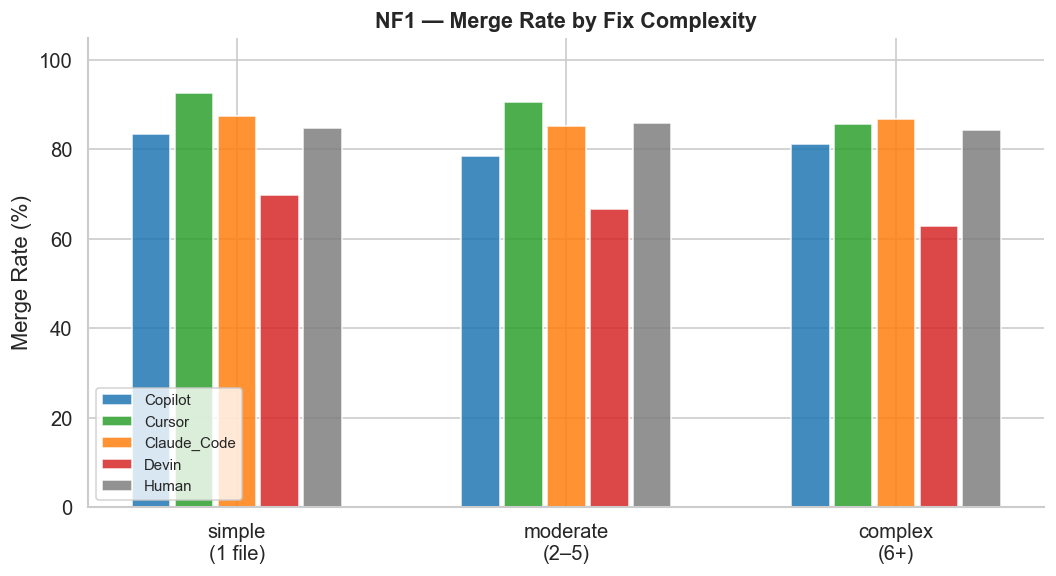

WindowsPath('results/theme6_figures/nf1_fix_complexity.png')

In [3]:
groups = AGENTS + ['Human']
colors = AGENT_COLORS

# Build rates table
rows = []
for grp in groups:
    sub = df_c[~df_c['is_agent']] if grp == 'Human' else df_c[df_c['agent'] == grp]
    for bkt in BUCKETS:
        b = sub[sub['complexity'] == bkt]
        if len(b) < MIN_N_PROP:
            continue
        _, _, rate = merge_rate(b)
        rows.append({'group': grp, 'complexity': bkt, 'rate': rate})

nf1 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(BUCKETS))
w = 0.13
for i, grp in enumerate(groups):
    g = nf1[nf1['group'] == grp]
    rates = [g[g['complexity'] == b]['rate'].values[0]
             if len(g[g['complexity'] == b]) else None for b in BUCKETS]
    valid = [(j, r) for j, r in enumerate(rates) if r is not None]
    if not valid: continue
    xs = [x[j] + (i - len(groups)/2 + 0.5)*w for j, _ in valid]
    ys = [r for _, r in valid]
    ax.bar(xs, ys, width=w*0.9, color=colors.get(grp, '#333'), alpha=0.85, label=grp)

ax.set_xticks(x)
ax.set_xticklabels(BUCKETS)
ax.set_ylabel('Merge Rate (%)')
ax.set_ylim(0, 105)
ax.set_title('NF1 — Merge Rate by Fix Complexity', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
save_fig(fig, 'nf1_fix_complexity', THEME6_DIR, show=True)

In [4]:
# Key number: simple vs complex drop, per group
print("NF1 KEY — Simple vs Complex merge rate drop:")
pvals, labels = [], []
for grp in groups:
    sub = df_c[~df_c['is_agent']] if grp == 'Human' else df_c[df_c['agent'] == grp]
    s = sub[sub['complexity'] == 'simple\n(1 file)']
    c = sub[sub['complexity'] == 'complex\n(6+)']
    if len(s) < MIN_N_PROP or len(c) < MIN_N_PROP: continue
    sm, st, sr = merge_rate(s); cm, ct, cr = merge_rate(c)
    _, p = chi_square(sm, st, cm, ct)
    or_, lo, hi = odds_ratio_ci(sm, st, cm, ct)
    pvals.append(p); labels.append((grp, sr, cr, or_, lo, hi))

adj = bh_correct(pvals)
for (grp, sr, cr, or_, lo, hi), ap in zip(labels, adj):
    print(f"  {grp:12s}: {sr:.0f}% → {cr:.0f}%  (drop={sr-cr:.1f}pp)  OR={or_:.2f}  {sig_label(ap)}")

NF1 KEY — Simple vs Complex merge rate drop:
  Copilot     : 84% → 81%  (drop=2.4pp)  OR=1.18  **
  Cursor      : 93% → 86%  (drop=6.9pp)  OR=2.08  ***
  Claude_Code : 87% → 87%  (drop=0.7pp)  OR=1.06  ns
  Devin       : 70% → 63%  (drop=6.8pp)  OR=1.36  ***
  Human       : 85% → 84%  (drop=0.6pp)  OR=1.04  *


---
## NF2 — Temporal Learning Curve

Monthly merge rate on a *relative* time axis (months since each agent's debut). Shows whether agents improve, decline, or stay flat over their platform lifetime.

NF2 KEY — Trend per agent since debut:
  Copilot     : decreasing   tau=-0.54  p=0.007


  Cursor      : decreasing   tau=-0.52  p=0.010
  Claude_Code : increasing   tau=+0.56  p=0.005
  Devin       : flat         tau=+0.30  p=0.157


  Human       : decreasing   tau=-0.78  p=0.000


  -> Saved: results\theme6_figures\nf2_learning_curve.png


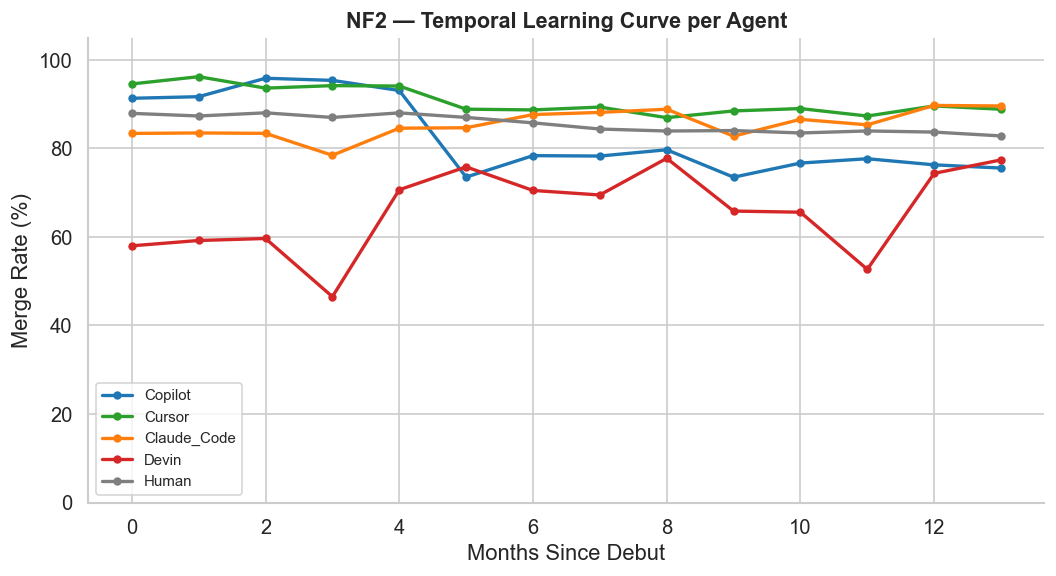

WindowsPath('results/theme6_figures/nf2_learning_curve.png')

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

print("NF2 KEY — Trend per agent since debut:")
for grp in AGENTS + ['Human']:
    sub = df[~df['is_agent']] if grp == 'Human' else df[df['agent'] == grp]
    monthly = (
        sub.groupby('month')
        .apply(lambda x: pd.Series({'n': len(x), 'merged': x['is_merged'].sum()}))
        .reset_index().sort_values('month')
    )
    debut_rows = monthly[monthly['n'] >= MIN_N_PROP]
    if debut_rows.empty: continue
    monthly = monthly[monthly['month'] >= debut_rows.iloc[0]['month']]
    monthly = monthly[monthly['n'] >= MIN_N_PROP].copy()
    monthly['rate'] = monthly['merged'] / monthly['n'] * 100
    monthly['t'] = range(len(monthly))

    tau, p, direction = trend_test(monthly['rate'].tolist())
    print(f"  {grp:12s}: {direction:11s}  tau={tau:+.2f}  p={p:.3f}")

    clr = AGENT_COLORS.get(grp, '#333')
    ax.plot(monthly['t'], monthly['rate'], color=clr, linewidth=2,
            marker='o', markersize=4, label=f"{grp}")

ax.set_xlabel('Months Since Debut')
ax.set_ylabel('Merge Rate (%)')
ax.set_ylim(0, 105)
ax.set_title('NF2 — Temporal Learning Curve per Agent', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'nf2_learning_curve', THEME6_DIR, show=True)

---
## NF3 — 24/7 Submission Patterns

Agents submit at all hours; humans follow work schedules. Does submitting during off-hours (outside Mon–Fri 09:00–17:00 UTC) slow down merging?

  -> Saved: results\theme6_figures\nf3_submission_patterns.png


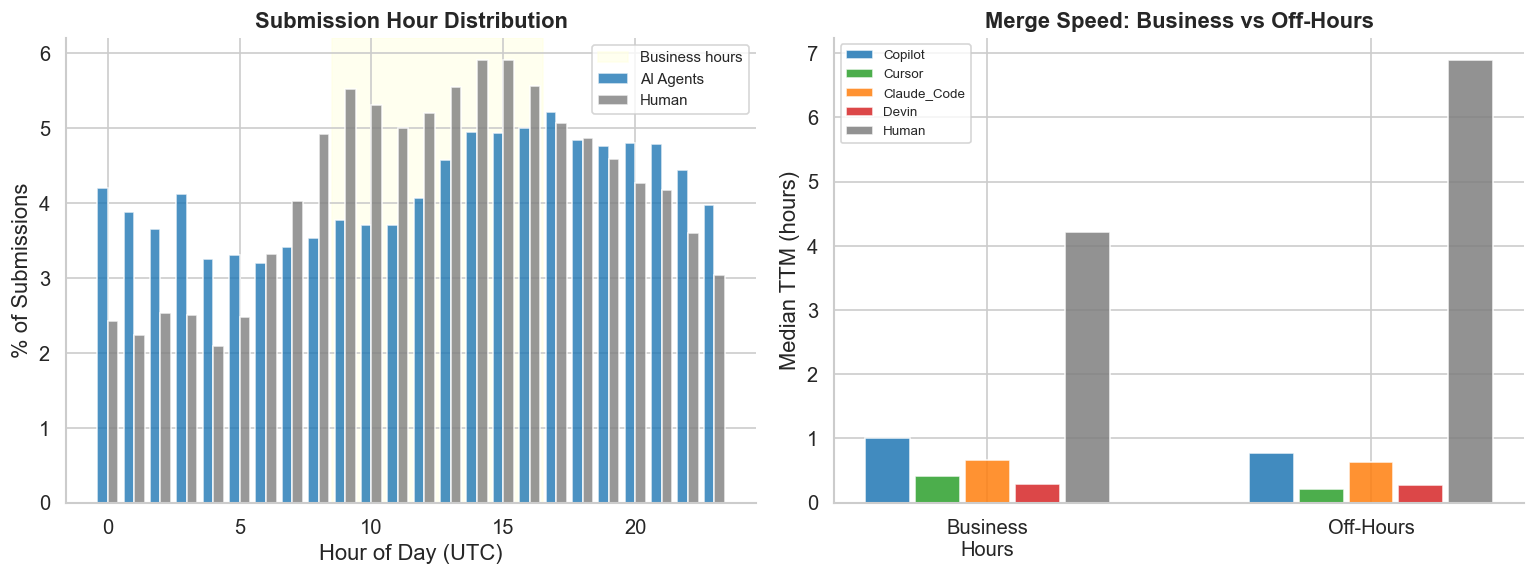

WindowsPath('results/theme6_figures/nf3_submission_patterns.png')

In [6]:
df['hour'] = df['created_at'].dt.hour
df['business_hours'] = (df['created_at'].dt.dayofweek < 5) & df['hour'].between(9, 16)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: hourly submission distribution
ax = axes[0]
hours = range(24)
a_pct = df[df['is_agent']].groupby('hour').size() / df['is_agent'].sum() * 100
h_pct = df[~df['is_agent']].groupby('hour').size() / (~df['is_agent']).sum() * 100

ax.bar([h - 0.2 for h in hours], [a_pct.get(h, 0) for h in hours],
       width=0.4, color='#1f77b4', alpha=0.8, label='AI Agents')
ax.bar([h + 0.2 for h in hours], [h_pct.get(h, 0) for h in hours],
       width=0.4, color='#7f7f7f', alpha=0.8, label='Human')
ax.axvspan(8.5, 16.5, color='lightyellow', zorder=0, alpha=0.5, label='Business hours')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('% of Submissions')
ax.set_title('Submission Hour Distribution', fontweight='bold')
ax.legend(fontsize=9)

# Right: median TTM business vs off-hours
ax2 = axes[1]
grp_labels = ['Business\nHours', 'Off-Hours']
x = np.arange(2)
w = 0.13
for i, grp in enumerate(AGENTS + ['Human']):
    sub = df[~df['is_agent'] & df['is_merged']] if grp == 'Human' else df[(df['agent']==grp) & df['is_merged']]
    biz = sub[sub['business_hours']]['hours_to_merge'].median()
    off = sub[~sub['business_hours']]['hours_to_merge'].median()
    offset = (i - 2) * w
    ax2.bar(x + offset, [biz, off], width=w*0.9,
            color=AGENT_COLORS.get(grp,'#333'), alpha=0.85, label=grp)

ax2.set_xticks(x)
ax2.set_xticklabels(grp_labels)
ax2.set_ylabel('Median TTM (hours)')
ax2.set_title('Merge Speed: Business vs Off-Hours', fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
save_fig(fig, 'nf3_submission_patterns', THEME6_DIR, show=True)

In [7]:
print("NF3 KEY — Off-hours fraction and TTM effect:")
a_off = (~df[df['is_agent']]['business_hours']).mean() * 100
h_off = (~df[~df['is_agent']]['business_hours']).mean() * 100
print(f"  Agents submit {a_off:.0f}% off-hours  |  Humans submit {h_off:.0f}% off-hours")

pvals, labels = [], []
for grp in AGENTS + ['Human']:
    sub = df[~df['is_agent'] & df['is_merged']] if grp == 'Human' else df[(df['agent']==grp) & df['is_merged']]
    biz = sub[sub['business_hours']]['hours_to_merge']
    off = sub[~sub['business_hours']]['hours_to_merge']
    if len(biz) < 20 or len(off) < 20: continue
    _, p = mann_whitney(biz, off)
    pvals.append(p); labels.append((grp, biz.median(), off.median()))

adj = bh_correct(pvals)
for (grp, bm, om), ap in zip(labels, adj):
    d, mag = cliffs_delta(pd.Series([om]), pd.Series([bm]))
    print(f"  {grp:12s}: biz={bm:.0f}h  off={om:.0f}h  {sig_label(ap)}")

NF3 KEY — Off-hours fraction and TTM effect:
  Agents submit 72% off-hours  |  Humans submit 60% off-hours


  Copilot     : biz=1h  off=1h  ***
  Cursor      : biz=0h  off=0h  ***
  Claude_Code : biz=1h  off=1h  ns
  Devin       : biz=0h  off=0h  ns
  Human       : biz=4h  off=7h  ***


---
## NF4 — Cross-Agent Repo Overlap

Some repos are used by only one agent; others attract multiple competing agents. Does having more agents in a repo signal a high-quality, actively-maintained codebase?

  -> Saved: results\theme6_figures\nf4_repo_overlap.png


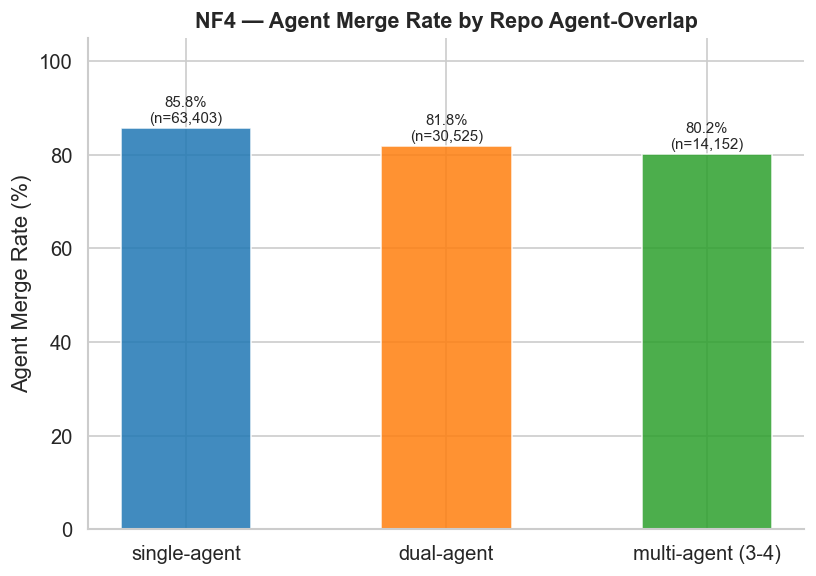

WindowsPath('results/theme6_figures/nf4_repo_overlap.png')

In [8]:
n_agents_repo = (
    df[df['is_agent']].groupby('repo')['agent'].nunique()
    .reset_index(name='n_agents')
)
n_agents_repo['overlap'] = n_agents_repo['n_agents'].map(
    {1: 'single-agent', 2: 'dual-agent'}
).fillna('multi-agent (3-4)')

df_o = df.merge(n_agents_repo[['repo','overlap']], on='repo', how='left')
df_o['overlap'] = df_o['overlap'].fillna('no-agent-repo')

OVERLAPS = ['single-agent', 'dual-agent', 'multi-agent (3-4)']
rows = []
for ov in OVERLAPS:
    sub = df_o[df_o['is_agent'] & (df_o['overlap'] == ov)]
    if len(sub) < MIN_N_PROP: continue
    _, _, rate = merge_rate(sub)
    rows.append({'overlap': ov, 'rate': rate, 'n': len(sub)})

nf4 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 5))
clrs = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(nf4['overlap'], nf4['rate'], color=clrs[:len(nf4)], alpha=0.85, width=0.5)
for bar, row in zip(bars, nf4.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row.rate:.1f}%\n(n={row.n:,})", ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Agent Merge Rate (%)')
ax.set_ylim(0, 105)
ax.set_title('NF4 — Agent Merge Rate by Repo Agent-Overlap', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'nf4_repo_overlap', THEME6_DIR, show=True)

In [9]:
print("NF4 KEY — single vs multi-agent repos:")
for row in nf4.itertuples():
    print(f"  {row.overlap:22s}: {row.rate:.1f}%  (n={row.n:,})")

s = df_o[df_o['is_agent'] & (df_o['overlap']=='single-agent')]
m = df_o[df_o['is_agent'] & (df_o['overlap']=='multi-agent (3-4)')]
if len(s) >= MIN_N_PROP and len(m) >= MIN_N_PROP:
    sm,st,_ = merge_rate(s); mm,mt,_ = merge_rate(m)
    or_, lo, hi = odds_ratio_ci(sm, st, mm, mt)
    _, p = chi_square(sm, st, mm, mt)
    adj = bh_correct([p])[0]
    print(f"\n  single vs multi-agent OR={or_:.2f} [{lo:.2f},{hi:.2f}]  {sig_label(adj)}")

NF4 KEY — single vs multi-agent repos:
  single-agent          : 85.8%  (n=63,403)
  dual-agent            : 81.8%  (n=30,525)
  multi-agent (3-4)     : 80.2%  (n=14,152)

  single vs multi-agent OR=1.49 [1.42,1.56]  ***
